# Tip for loading Data file.

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Replace 'path/to/your/csv/file.csv' with the actual path to your file in Google Drive
# For example, if your file is in a folder named 'my_data' in your Drive, the path would be '/content/drive/MyDrive/my_data/your_file.csv'
csv_path = '/content/drive/MyDrive/OPS Hackathon/Text Description Classification/synthetic_transactions_diverse.csv'

# Read the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(csv_path)
    print("CSV file loaded successfully!")
    display(df.head()) # Display the first few rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file '{csv_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
CSV file loaded successfully!


,text_description,category
0,Procured legal fee and contract review for €36...,Legal
1,"Bought annual fee, membership for CAD$1,244.45...",Subscriptions
2,"Spent onn charger, laptop, mouse for $602.94, ...",Electronics
3,Bought workshop and course fee for ₹286 and JP...,Training
4,"Purchased diesel, petrol, gasoline (incl. gaso...",Fuel


In [ ]:
from google.colab import drive
drive.flush_and_unmount()


OR

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/OneNishitRathod/Text-Description-Classification/refs/heads/Dev/synthetic_transactions_diverse.csv')

In [ ]:
df.head()

,text_description,category
0,Procured legal fee and contract review for €36...,Legal
1,"Bought annual fee, membership for CAD$1,244.45...",Subscriptions
2,"Spent onn charger, laptop, mouse for $602.94, ...",Electronics
3,Bought workshop and course fee for ₹286 and JP...,Training
4,"Purchased diesel, petrol, gasoline (incl. gaso...",Fuel


# Anatole Farber - Implementation

#### Write your observation: [Classification Tracker](https://docs.google.com/spreadsheets/d/1Pb3ryHwrBZLUZXm_x_-a0evyA-EOY4acN7AHCLOHrwE/edit?usp=sharing)

# Andrew Chen - Implementation

#### Write your observation: [Classification Tracker](https://docs.google.com/spreadsheets/d/1Pb3ryHwrBZLUZXm_x_-a0evyA-EOY4acN7AHCLOHrwE/edit?usp=sharing)

# Kenny Hoang - Implementation

#### Write your observation: [Classification Tracker](https://docs.google.com/spreadsheets/d/1Pb3ryHwrBZLUZXm_x_-a0evyA-EOY4acN7AHCLOHrwE/edit?usp=sharing)

# Lily S. Nickoshie - Implementation

#### Write your observation: [Classification Tracker](https://docs.google.com/spreadsheets/d/1Pb3ryHwrBZLUZXm_x_-a0evyA-EOY4acN7AHCLOHrwE/edit?usp=sharing)

# Nishit Rathod - Implementation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/OneNishitRathod/Text-Description-Classification/refs/heads/Dev/synthetic_transactions_diverse.csv')

In [3]:
df.head()

,text_description,category
0,Procured legal fee and contract review for €36...,Legal
1,"Bought annual fee, membership for CAD$1,244.45...",Subscriptions
2,"Spent onn charger, laptop, mouse for $602.94, ...",Electronics
3,Bought workshop and course fee for ₹286 and JP...,Training
4,"Purchased diesel, petrol, gasoline (incl. gaso...",Fuel


In [4]:
X = df["text_description"]
y = df["category"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [5]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", use_label_encoder=False, random_state=42),
    "Naive Bayes": MultinomialNB()
}


 Training Random Forest...

 Training Logistic Regression...

 Training Linear SVM...

 Training XGBoost...

 Training Naive Bayes...


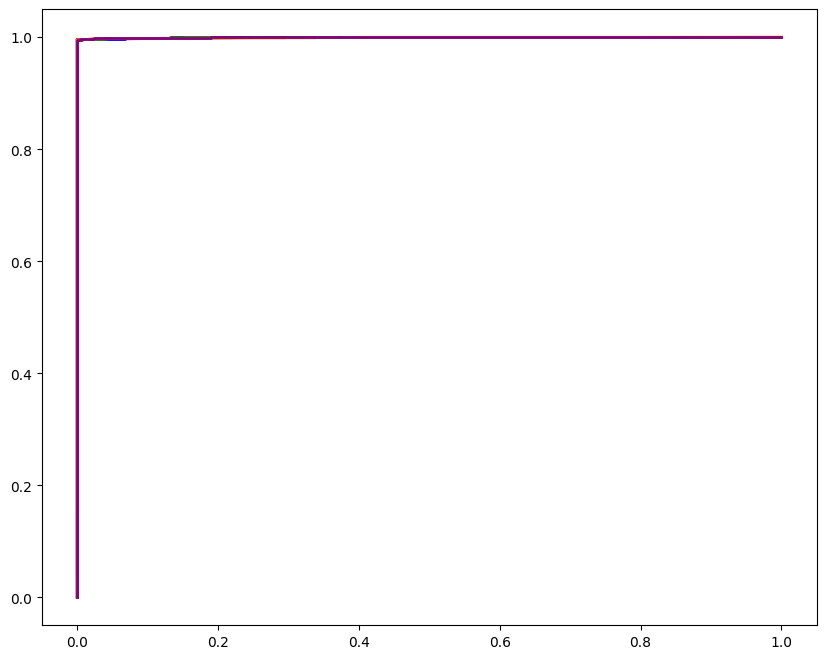

In [6]:
eval_rows = []
plt.figure(figsize=(10, 8))

colors = cycle(["red", "blue", "green", "orange", "purple"])

for color, (name, model) in zip(colors, models.items()):
    print(f"\n Training {name}...")
    # Wrap in OneVsRest for multiclass ROC support
    clf = OneVsRestClassifier(model)
    clf.fit(X_train_vec, label_binarize(y_train, classes=range(n_classes)))
    y_pred = clf.predict(X_test_vec)
    y_pred_labels = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_test, y_pred_labels)
    prec = precision_score(y_test, y_pred_labels, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred_labels, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred_labels, average="weighted", zero_division=0)

    eval_rows.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    # ROC CURVE
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test_vec)
    else:
        try:
            y_score = clf.decision_function(X_test_vec)
        except:
            continue  # skip if not supported

    fpr, tpr, _ = roc_curve(label_binarize(y_test, classes=range(n_classes)).ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")


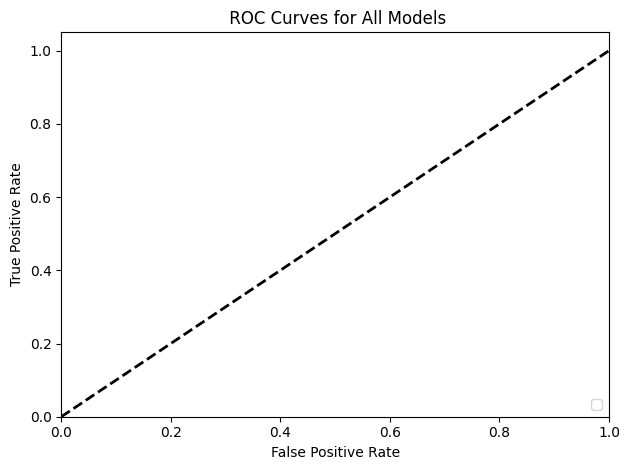

In [7]:
plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title(" ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [8]:
eval_df = pd.DataFrame(eval_rows).sort_values(by="Accuracy", ascending=False)
print("\n Model Evaluation Summary:")
print(eval_df)


 Model Evaluation Summary:
                 Model  Accuracy  Precision    Recall        F1
0        Random Forest  0.990000   0.991667  0.990000  0.990401
3              XGBoost  0.987333   0.989894  0.987333  0.987983
2           Linear SVM  0.981667   0.986585  0.981667  0.982957
4          Naive Bayes  0.944667   0.973734  0.944667  0.953523
1  Logistic Regression  0.905667   0.967321  0.905667  0.925678


In [9]:
best_model_name = eval_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train_vec, y_train)  # refit for label prediction use

print(f"\n Using best model: {best_model_name}")

def predict_user_input(user_text):
    """Predict Top-3 categories for user input."""
    user_vec = vectorizer.transform([user_text])

    if hasattr(best_model, "predict_proba"):
        probs = best_model.predict_proba(user_vec)[0]
    else:
        try:
            probs = best_model.decision_function(user_vec)[0]
            probs = (probs - probs.min()) / (probs.max() - probs.min())
        except:
            probs = np.zeros(len(le.classes_))

    top_idx = np.argsort(probs)[::-1][:3]
    top_labels = le.inverse_transform(top_idx)
    top_scores = probs[top_idx]

    print("\n Prediction Results:")
    for i in range(3):
        print(f"{i+1}. {top_labels[i]} ({top_scores[i]*100:.2f}% confidence)")


 Using best model: Random Forest


In [10]:
while True:
    user_text = input("\nEnter Description (or type 'exit'): ")
    if user_text.lower() == "exit":
        break
    predict_user_input(user_text)


Enter Description (or type 'exit'): Bought a pair of jeans and shoes from Walmart

 Prediction Results:
1. Clothing (92.67% confidence)
2. Groceries (2.00% confidence)
3. Utilities (1.33% confidence)

Enter Description (or type 'exit'): Donated 100 dollars to United ClimbUp Foundation

 Prediction Results:
1. Training (10.67% confidence)
2. Healthcare (10.67% confidence)
3. Stationery (8.00% confidence)

Enter Description (or type 'exit'): Purchased 3 wireless Bluetooth headphones, 2 USB-C charging cables, and 1 laptop stand from BestBuy Toronto outlet via online store checkout. Applied summer discount code and selected standard shipping with total billing of $312.45 including taxes. Order processed successfully on June 14, 2024 with transaction ID TX98455 and shipped to Ontario, Canada.

 Prediction Results:
1. Electronics (64.00% confidence)
2. Shipping (30.67% confidence)
3. Groceries (1.33% confidence)

Enter Description (or type 'exit'): Flight booking for business trip from Toro

#### Write your observation: [Classification Tracker](https://docs.google.com/spreadsheets/d/1Pb3ryHwrBZLUZXm_x_-a0evyA-EOY4acN7AHCLOHrwE/edit?usp=sharing)

# Yanzhen Zhang - Implementation

#### Write your observation: [Classification Tracker](https://docs.google.com/spreadsheets/d/1Pb3ryHwrBZLUZXm_x_-a0evyA-EOY4acN7AHCLOHrwE/edit?usp=sharing)